# Tratamiento de Datos Faltantes 
## Dataset: Rotación de Empleados (IBM HR Analytics)


In [1]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# IMPORTANTE: enable_iterative_imputer debe importarse ANTES que KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
sns.set_palette('tab10')

# Carga y limpieza básica (misma del notebook anterior)
DB_PATH = Path().resolve().parent / "data" / "raw" / "dataset_clasificacion.csv"

df_original = pd.read_csv(DB_PATH)
str_cols = df_original.select_dtypes(include='object').columns
for col in str_cols:
    df_original[col] = (df_original[col].astype(str).str.strip()
                        .str.lower()
                        .str.replace(r'[^a-z0-9 _&\-]', '', regex=True))

print(f"Dataset cargado: {df_original.shape[0]} filas × {df_original.shape[1]} columnas")
print(f"Datos faltantes originales: {df_original.isnull().sum().sum()}")

Dataset cargado: 1470 filas × 35 columnas
Datos faltantes originales: 0


---
## 1. Selección de Variables y Eliminación Aleatoria de Datos

Se seleccionan **6 variables numéricas** de distintos dominios del dataset.
Se elimina un porcentaje aleatorio de sus valores (entre 10 % y 20 %) usando
una **semilla fija (42)** para garantizar reproducibilidad.

| Variable | Dominio | % eliminado |
|---|---|---|
| `MonthlyIncome` | Compensación — USD/mes | 15 % |
| `Age` | Demografía — años | 10 % |
| `DailyRate` | Compensación — USD/día | 20 % |
| `TotalWorkingYears` | Experiencia — años | 12 % |
| `DistanceFromHome` | Geografía — km | 18 % |
| `YearsAtCompany` | Antigüedad — años | 10 % |

In [2]:
SEED = 42
np.random.seed(SEED)

TARGET_VARS = {
    'MonthlyIncome'    : 0.15,
    'Age'              : 0.10,
    'DailyRate'        : 0.20,
    'TotalWorkingYears': 0.12,
    'DistanceFromHome' : 0.18,
    'YearsAtCompany'   : 0.10,
}

UNITS = {
    'MonthlyIncome':'USD/mes', 'Age':'años', 'DailyRate':'USD/día',
    'TotalWorkingYears':'años', 'DistanceFromHome':'km', 'YearsAtCompany':'años'
}

df_missing = df_original.copy()

print(f"{'Variable':<22} {'Filas eliminadas':>18} {'Porcentaje':>12}")
print("-" * 54)
for var, pct in TARGET_VARS.items():
    n_remove = int(len(df_missing) * pct)
    idx_remove = np.random.choice(df_missing.index, size=n_remove, replace=False)
    df_missing.loc[idx_remove, var] = np.nan
    print(f"{var:<22} {n_remove:>18} {pct*100:>11.0f} %")

print(f"\nTotal de NaN generados: {df_missing[list(TARGET_VARS)].isnull().sum().sum()}")

Variable                 Filas eliminadas   Porcentaje
------------------------------------------------------
MonthlyIncome                         220          15 %
Age                                   147          10 %
DailyRate                             294          20 %
TotalWorkingYears                     176          12 %
DistanceFromHome                      264          18 %
YearsAtCompany                        147          10 %

Total de NaN generados: 1248


### 1.1 Mapa visual de datos faltantes

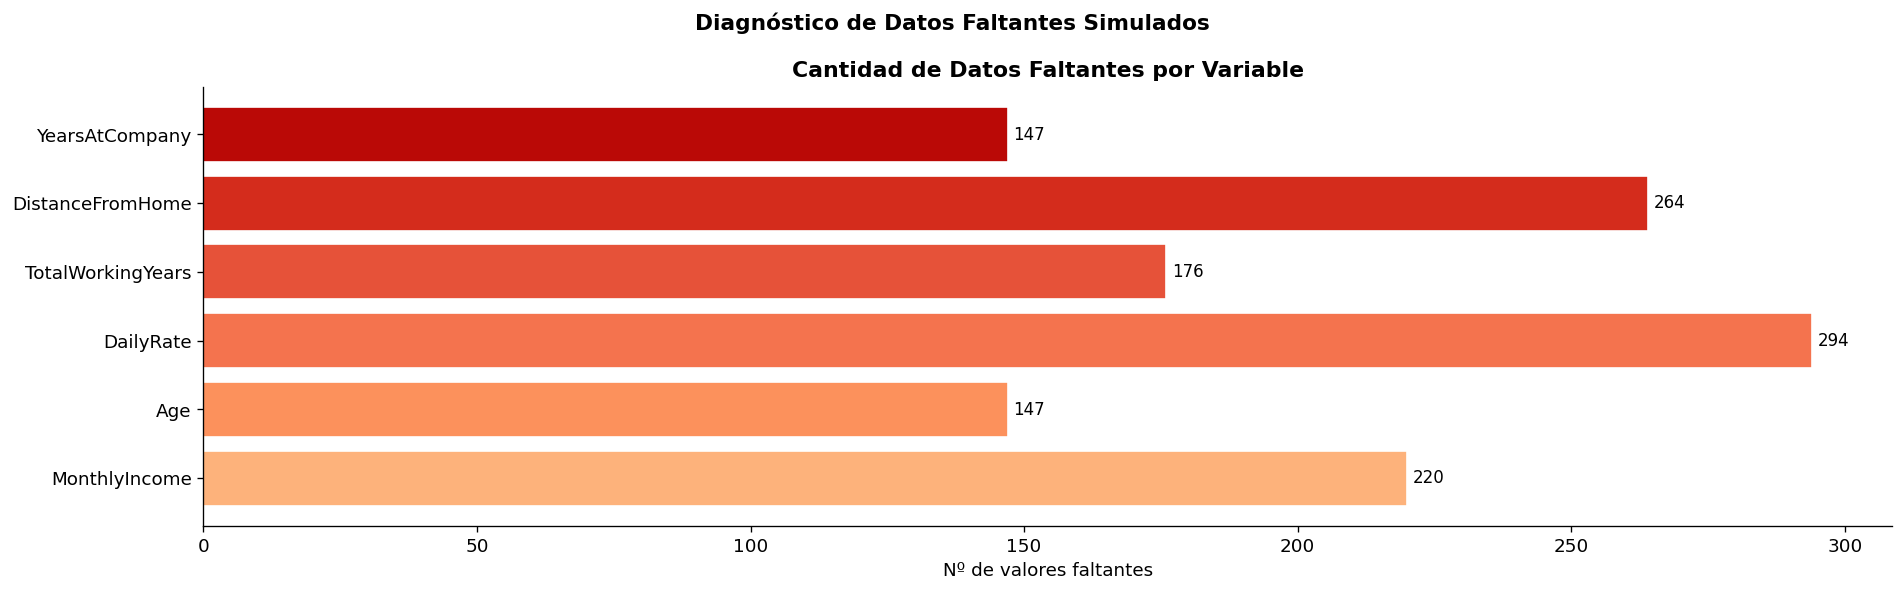

In [9]:
fig, axes = plt.subplots(figsize=(16, 5))

# Barras de conteo
miss_counts = df_missing[list(TARGET_VARS)].isnull().sum()
colors = plt.cm.OrRd(np.linspace(0.4, 0.85, len(miss_counts)))
bars = axes.barh(miss_counts.index, miss_counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, miss_counts.values):
    axes.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=10)
axes.set_title('Cantidad de Datos Faltantes por Variable', fontweight='bold')
axes.set_xlabel('Nº de valores faltantes')


plt.suptitle('Diagnóstico de Datos Faltantes Simulados', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('missing_diagnostico.png', bbox_inches='tight')
plt.show()

---
## 2. Métodos de Imputación Aplicados

### Método A — Medidas de Tendencia Central (MTC)
Reemplaza cada valor faltante con un estadístico global calculado sobre los
datos disponibles de esa columna:
- **Media** → cuando la distribución es simétrica (|skewness| < 0.5).
- **Mediana** → cuando hay sesgo o valores atípicos (|skewness| ≥ 0.5).

Es el método más simple, rápido e interpretable, pero imputa **un único valor
constante**, lo que reduce la varianza de la variable y no considera relaciones con otras columnas.

### Método B — KNN Imputer (*K-Nearest Neighbors*, k = 5)
Para cada fila con valor faltante, identifica las **5 filas más similares**
(vecinos más cercanos en el espacio de las demás variables numéricas) y calcula
un promedio ponderado por distancia inversa. Captura relaciones multivariadas
y produce valores más contextualizados al perfil del empleado.

In [10]:
# ── Método A: Medidas de Tendencia Central ────────────────────────────────────
df_mtc = df_missing.copy()

skewness = df_original[list(TARGET_VARS)].skew()
print(f"{'Variable':<22} {'|Skewness|':>12} {'Método':>10} {'Valor imputado':>16}")
print("-" * 64)

mtc_details = {}
for var in TARGET_VARS:
    sk = abs(skewness[var])
    if sk < 0.5:
        val = df_missing[var].mean()
        method = 'media'
    else:
        val = df_missing[var].median()
        method = 'mediana'
    df_mtc[var] = df_mtc[var].fillna(val)
    mtc_details[var] = (method, round(val, 2))
    print(f"{var:<22} {sk:>12.3f} {method:>10} {val:>16.2f}")

print("\n✔  Imputación MTC completada — 0 valores faltantes restantes:",
      df_mtc[list(TARGET_VARS)].isnull().sum().sum())

Variable                 |Skewness|     Método   Valor imputado
----------------------------------------------------------------
MonthlyIncome                 1.370    mediana          4774.50
Age                           0.413      media            37.03
DailyRate                     0.004      media           803.99
TotalWorkingYears             1.117    mediana            10.00
DistanceFromHome              0.958    mediana             7.00
YearsAtCompany                1.765    mediana             5.00

✔  Imputación MTC completada — 0 valores faltantes restantes: 0


In [11]:
# ── Método B: KNN Imputer ─────────────────────────────────────────────────────
# Se usan TODAS las columnas numéricas como espacio de vecinos
num_all = df_missing.select_dtypes(include=[np.number]).columns.tolist()

knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
df_knn = df_missing.copy()
df_knn[num_all] = knn_imputer.fit_transform(df_missing[num_all])

print("✔  Imputación KNN (k=5, pesos por distancia inversa) completada.")
print(f"   Variables numéricas usadas como contexto: {len(num_all)}")
print(f"   Valores faltantes restantes: {df_knn[list(TARGET_VARS)].isnull().sum().sum()}")

✔  Imputación KNN (k=5, pesos por distancia inversa) completada.
   Variables numéricas usadas como contexto: 26
   Valores faltantes restantes: 0


---
## 3. Comparación de Resultados

La comparación se realiza en cuatro dimensiones:
1. **Estadísticas descriptivas** — media, mediana, desviación estándar y asimetría.  
2. **Distribuciones** — histogramas y KDE superpuestos.  
3. **Dispersión** — boxplots comparativos.  
4. **Error cuantitativo** — MAE y RMSE sobre los valores reales conocidos.

### 3.1 Tabla de estadísticas descriptivas: Original vs MTC vs KNN

In [12]:
rows = []
for var in TARGET_VARS:
    for label, dframe in [('Original', df_original),
                           ('MTC',      df_mtc),
                           ('KNN',      df_knn)]:
        s = dframe[var]
        rows.append({
            'Variable': var, 'Método': label,
            'Media'          : round(s.mean(), 2),
            'Mediana'        : round(s.median(), 2),
            'Desv. Estándar' : round(s.std(), 2),
            'Asimetría'      : round(s.skew(), 3),
        })

comp_df = pd.DataFrame(rows).set_index(['Variable','Método'])
print(comp_df.to_string())

                              Media  Mediana  Desv. Estándar  Asimetría
Variable          Método                                               
MonthlyIncome     Original  6502.93  4919.00         4707.96      1.370
                  MTC       6177.70  4774.50         4402.24      1.624
                  KNN       6391.36  4988.50         4450.40      1.446
Age               Original    36.92    36.00            9.14      0.413
                  MTC         37.03    37.00            8.71      0.418
                  KNN         37.06    36.00            8.83      0.395
DailyRate         Original   802.49   802.00          403.51     -0.004
                  MTC        803.99   803.99          360.31     -0.031
                  KNN        803.18   797.50          370.34     -0.023
TotalWorkingYears Original    11.28    10.00            7.78      1.117
                  MTC         11.22    10.00            7.44      1.239
                  KNN         11.28    10.00            7.52    

### 3.2 Histogramas: Original vs MTC vs KNN

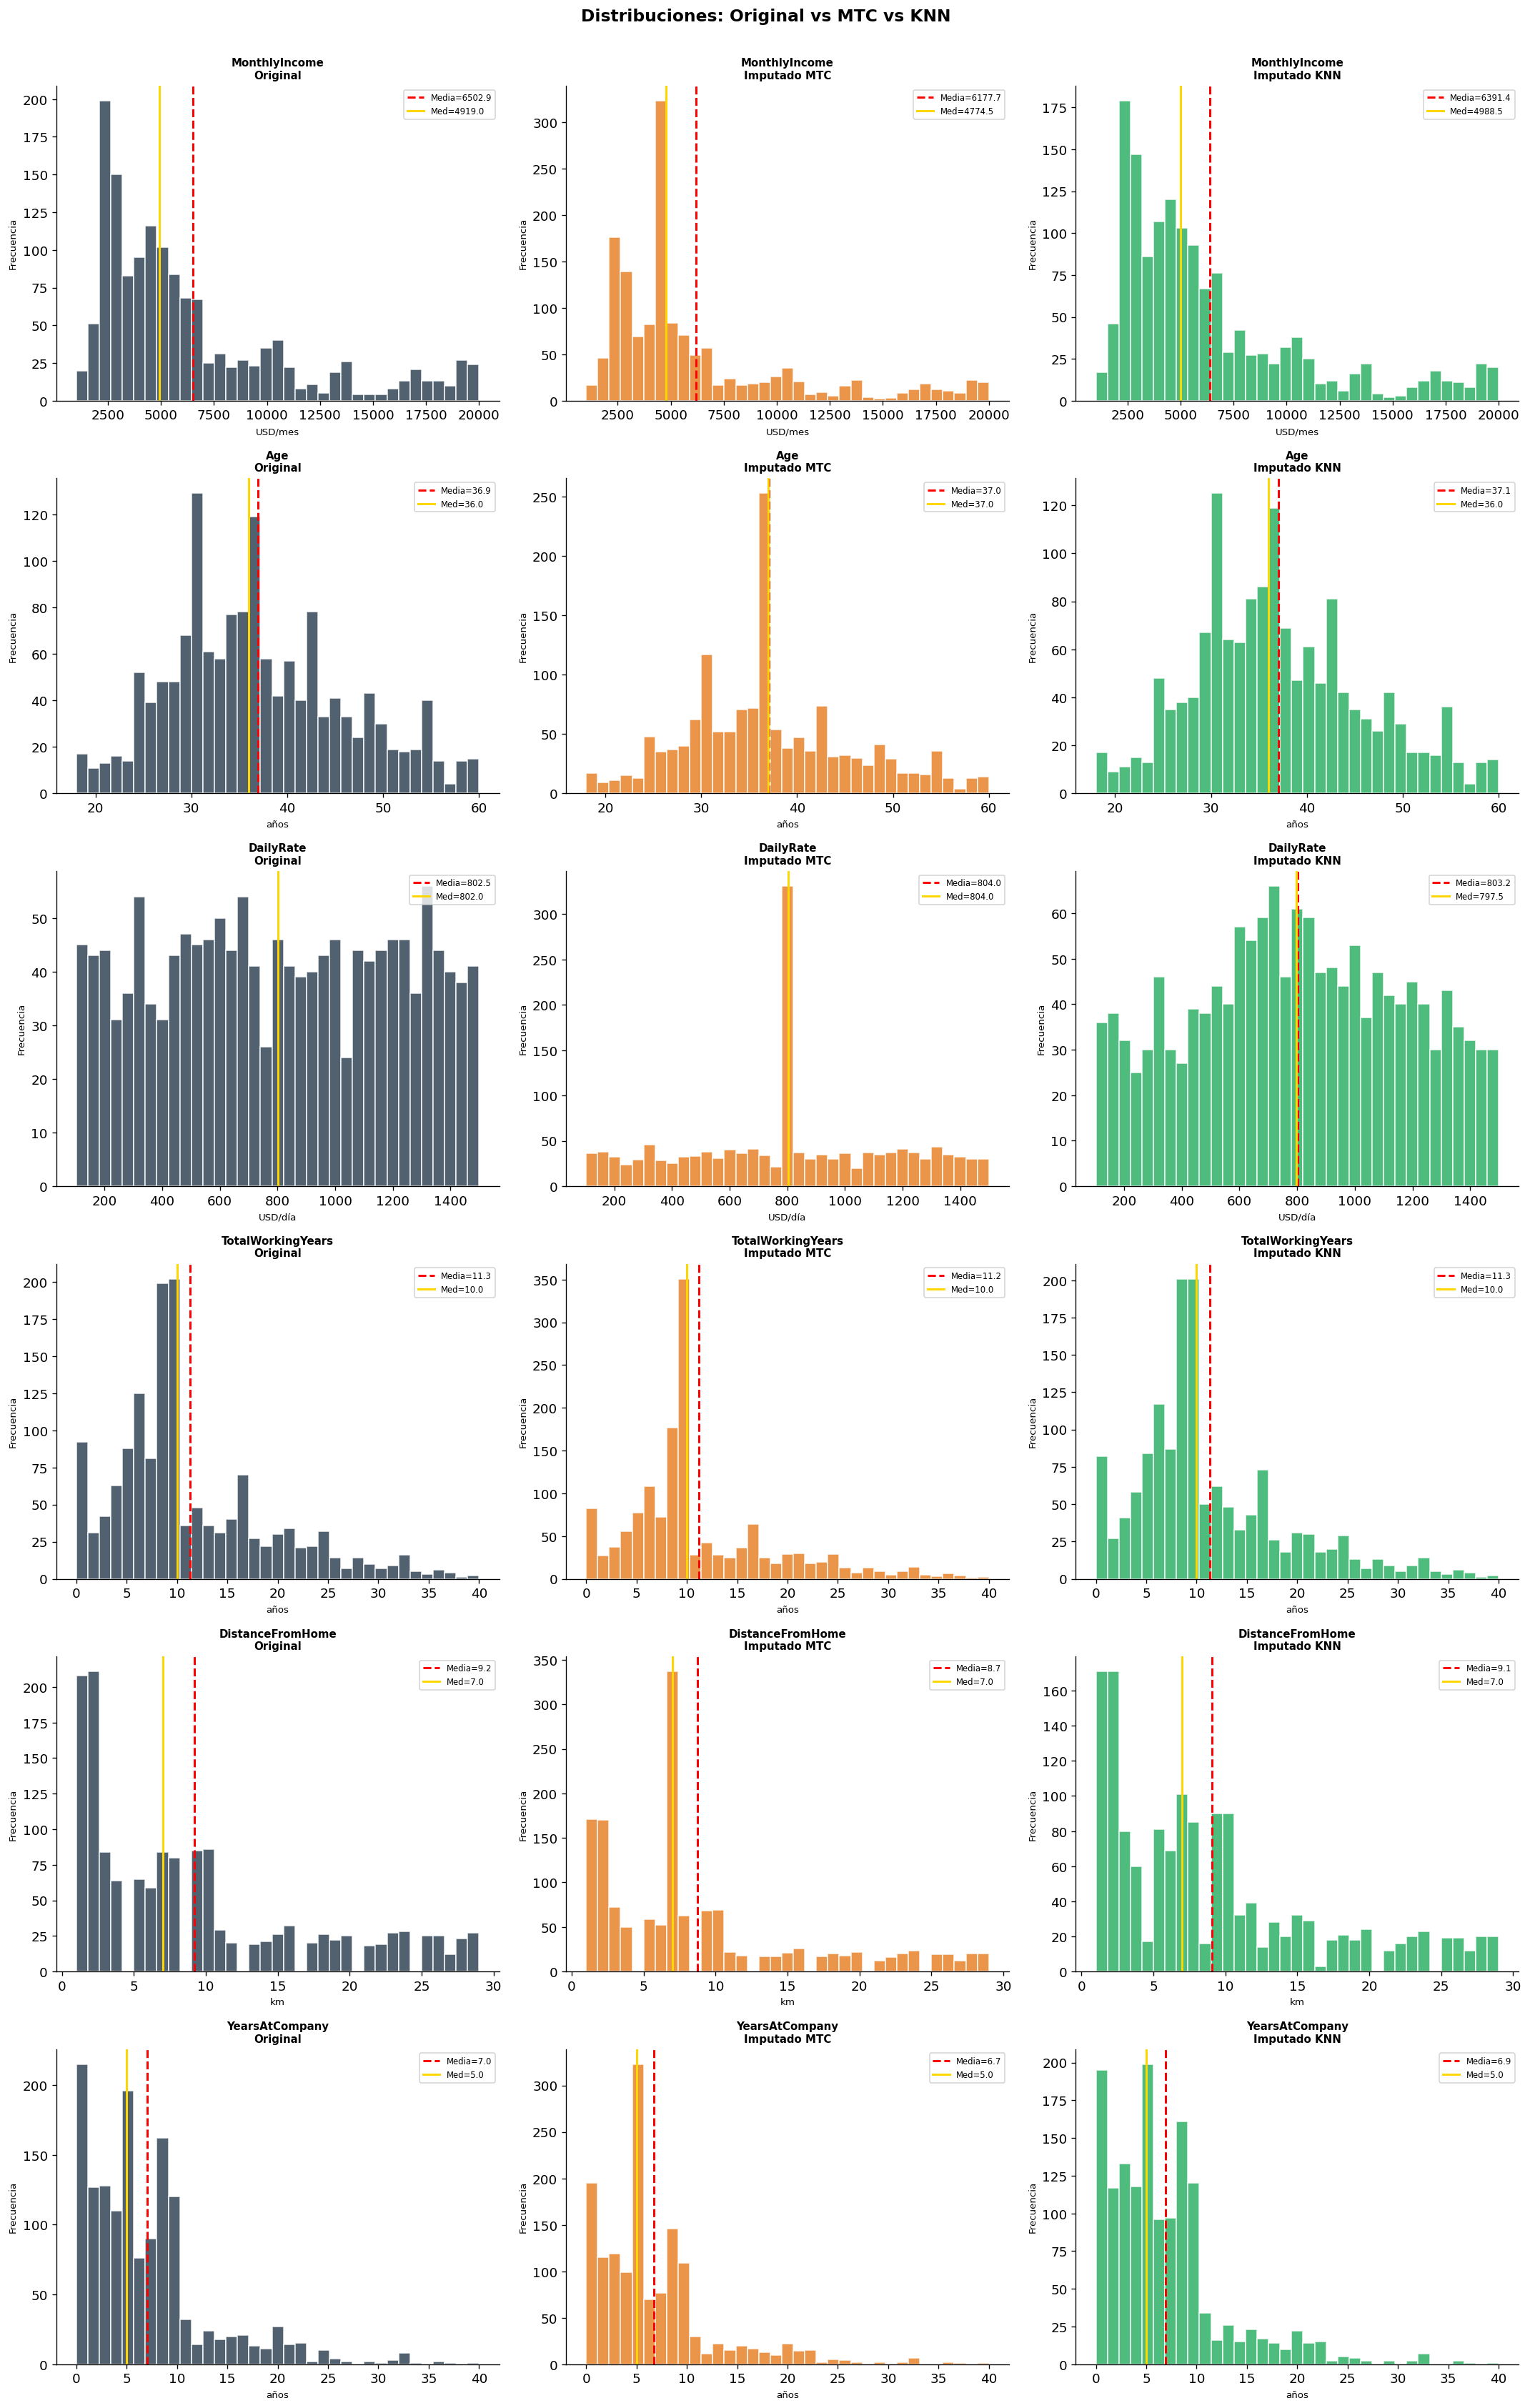

In [13]:
fig, axes = plt.subplots(6, 3, figsize=(18, 28))

col_configs = [
    (df_original, '#2c3e50', 'Original'),
    (df_mtc,      '#e67e22', 'Imputado MTC'),
    (df_knn,      '#27ae60', 'Imputado KNN'),
]

for i, var in enumerate(TARGET_VARS):
    bins = 35
    for j, (dframe, color, label) in enumerate(col_configs):
        ax = axes[i, j]
        data = dframe[var].dropna()
        ax.hist(data, bins=bins, color=color, alpha=0.82, edgecolor='white')
        ax.axvline(data.mean(),   color='red',  linestyle='--', lw=1.8,
                   label=f'Media={data.mean():.1f}')
        ax.axvline(data.median(), color='gold', linestyle='-',  lw=1.8,
                   label=f'Med={data.median():.1f}')
        ax.set_title(f'{var}\n{label}', fontweight='bold', fontsize=9)
        ax.set_xlabel(UNITS.get(var,''), fontsize=8)
        ax.set_ylabel('Frecuencia', fontsize=8)
        ax.legend(fontsize=7)

fig.suptitle('Distribuciones: Original vs MTC vs KNN',
             fontsize=14, fontweight='bold', y=1.002)
plt.tight_layout()
plt.savefig('comparacion_histogramas.png', bbox_inches='tight')
plt.show()

### 3.3 KDE superpuesto — forma de la distribución

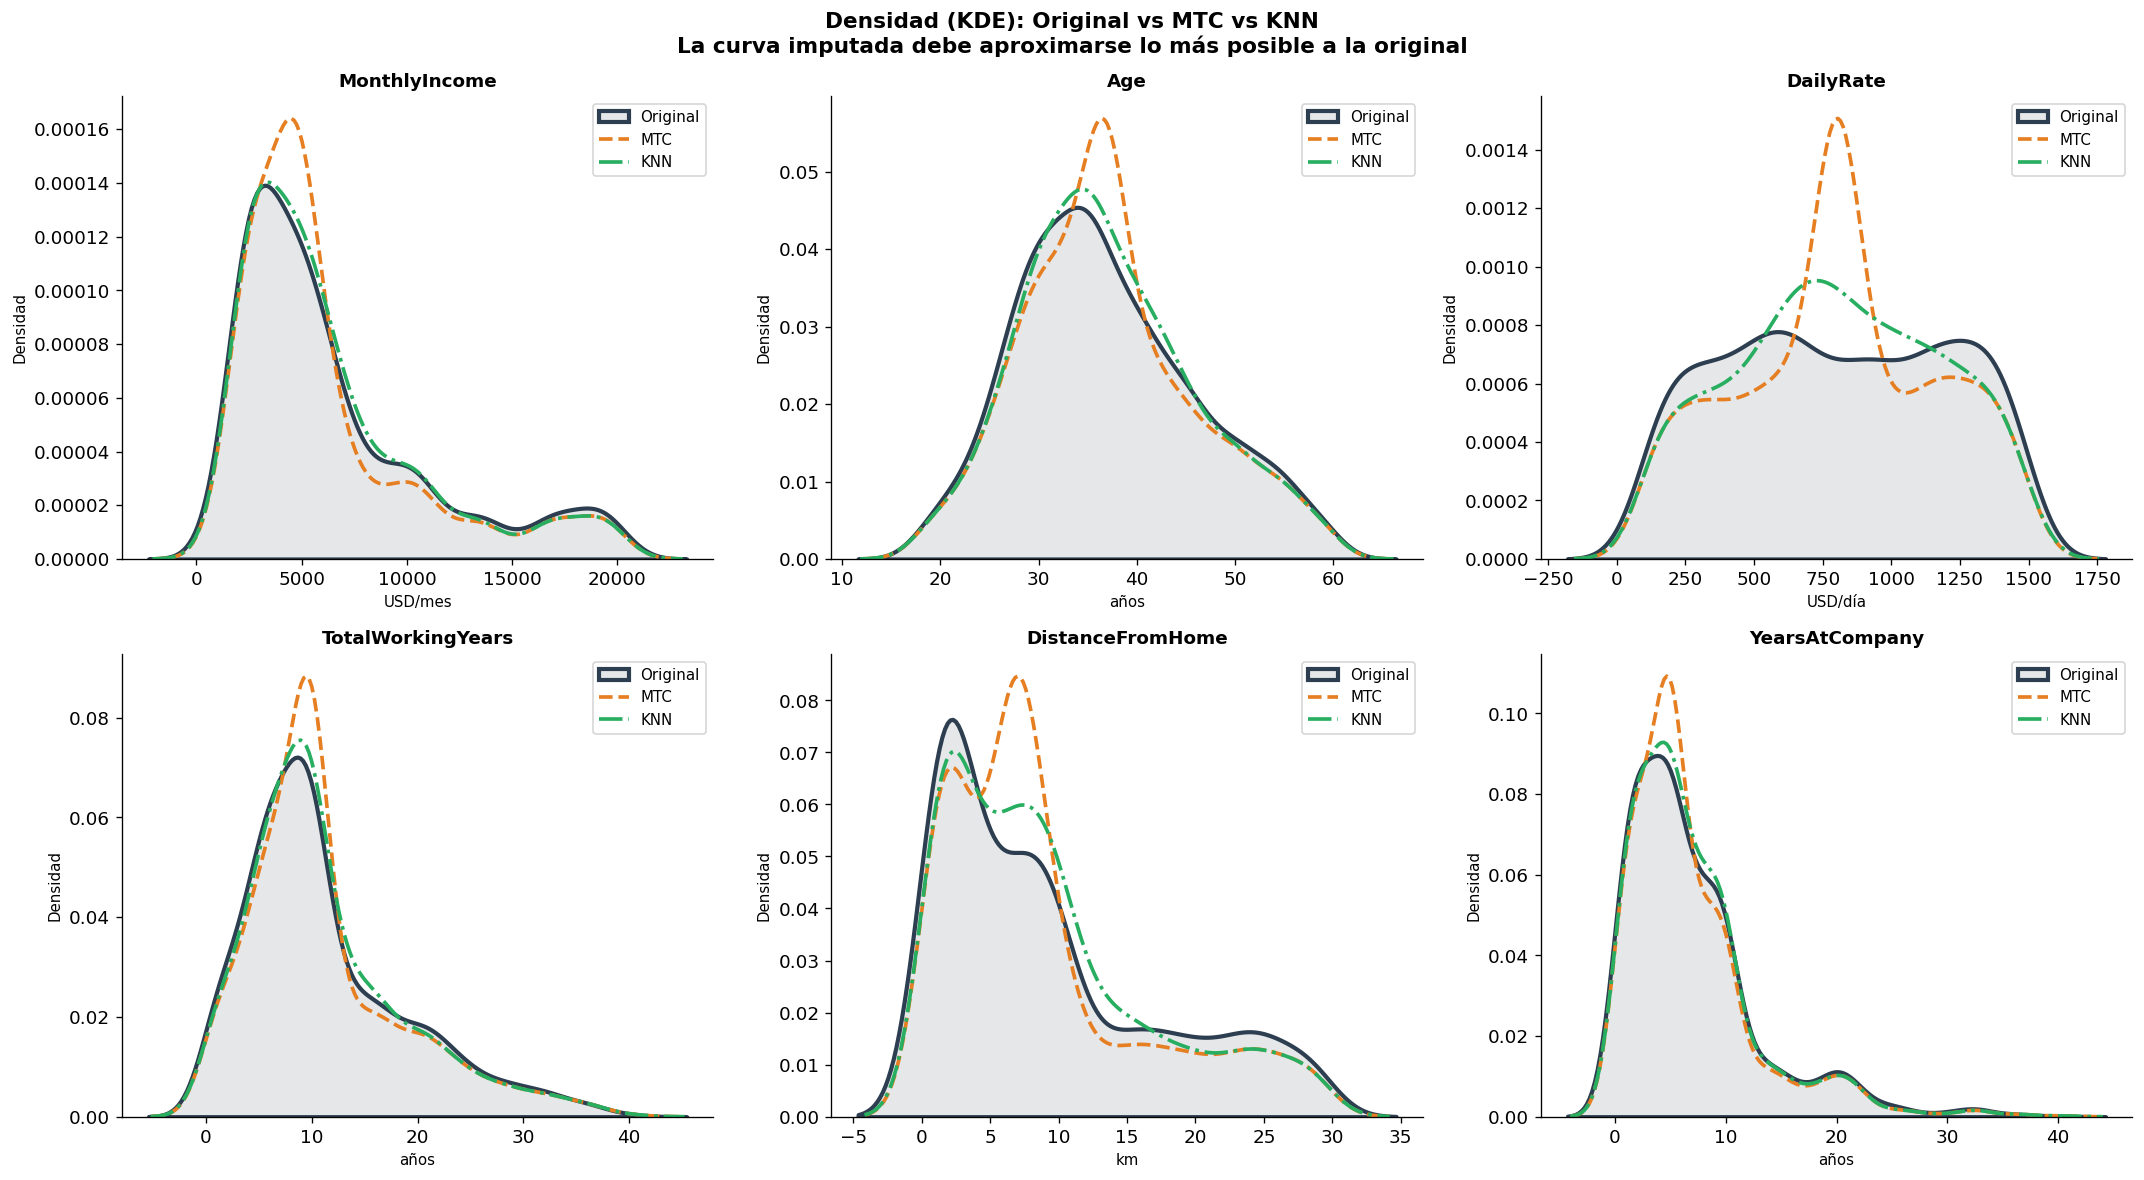

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(TARGET_VARS):
    ax = axes[i]
    sns.kdeplot(df_original[var].dropna(), ax=ax, color='#2c3e50', lw=2.5,
                label='Original', fill=True, alpha=0.12)
    sns.kdeplot(df_mtc[var], ax=ax, color='#e67e22', lw=2.2,
                linestyle='--', label='MTC')
    sns.kdeplot(df_knn[var], ax=ax, color='#27ae60', lw=2.2,
                linestyle='-.', label='KNN')
    ax.set_title(var, fontweight='bold', fontsize=11)
    ax.set_xlabel(UNITS.get(var,''), fontsize=9)
    ax.set_ylabel('Densidad', fontsize=9)
    ax.legend(fontsize=9)

fig.suptitle('Densidad (KDE): Original vs MTC vs KNN\n'
             'La curva imputada debe aproximarse lo más posible a la original',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_kde.png', bbox_inches='tight')
plt.show()

### 3.4 Boxplots comparativos — dispersión e IQR

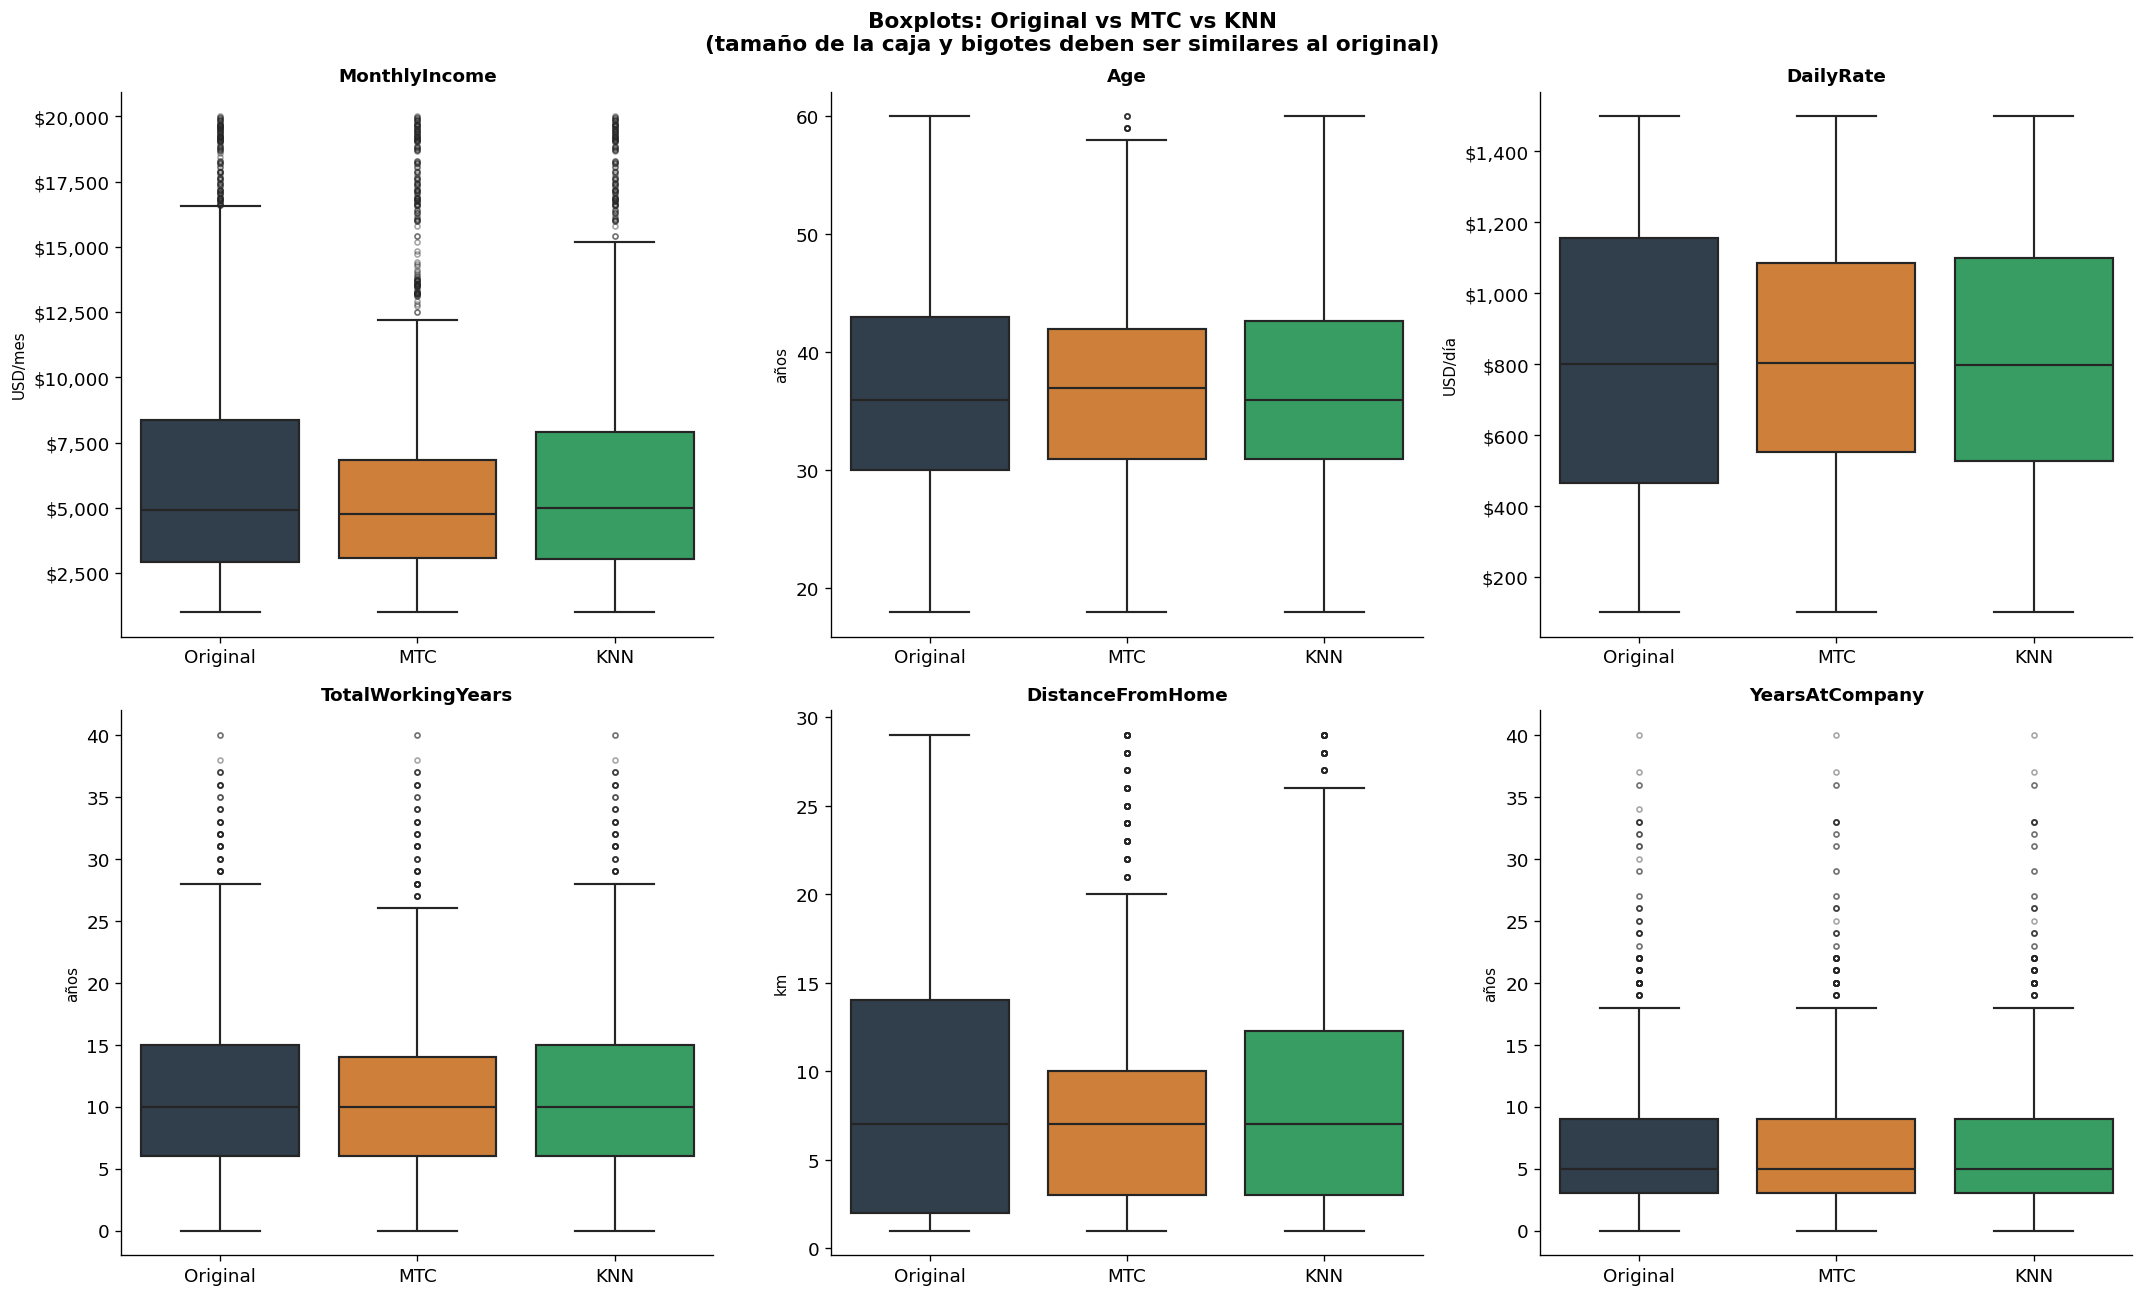

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

palette_box = {'Original':'#2c3e50', 'MTC':'#e67e22', 'KNN':'#27ae60'}

for i, var in enumerate(TARGET_VARS):
    ax = axes[i]
    df_box = pd.DataFrame({
        'Original': df_original[var].values,
        'MTC'     : df_mtc[var].values,
        'KNN'     : df_knn[var].values,
    })
    df_melt = df_box.melt(var_name='Método', value_name='Valor')
    sns.boxplot(data=df_melt, x='Método', y='Valor',
                palette=palette_box, order=['Original','MTC','KNN'], ax=ax,
                linewidth=1.3, flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(var, fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel(UNITS.get(var,''), fontsize=9)
    if 'Income' in var or 'Rate' in var:
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

fig.suptitle('Boxplots: Original vs MTC vs KNN\n'
             '(tamaño de la caja y bigotes deben ser similares al original)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_boxplots.png', bbox_inches='tight')
plt.show()

### 3.5 Error cuantitativo — MAE y RMSE sobre valores reales

In [16]:
# Reconstruir las máscaras con la misma semilla para recuperar los índices eliminados
np.random.seed(SEED)

error_rows = []
for var, pct in TARGET_VARS.items():
    n_remove = int(len(df_original) * pct)
    idx_removed = np.random.choice(df_original.index, size=n_remove, replace=False)

    real     = df_original.loc[idx_removed, var].values
    pred_mtc = df_mtc.loc[idx_removed, var].values
    pred_knn = df_knn.loc[idx_removed, var].values

    mae_mtc  = np.mean(np.abs(real - pred_mtc))
    rmse_mtc = np.sqrt(np.mean((real - pred_mtc)**2))
    mae_knn  = np.mean(np.abs(real - pred_knn))
    rmse_knn = np.sqrt(np.mean((real - pred_knn)**2))

    # Preservación de varianza (diferencia absoluta de std respecto al original)
    std_orig = df_original[var].std()
    dstd_mtc = abs(df_mtc[var].std() - std_orig)
    dstd_knn = abs(df_knn[var].std() - std_orig)

    error_rows.append({
        'Variable'       : var,
        'MAE MTC'        : round(mae_mtc,  2),
        'MAE KNN'        : round(mae_knn,  2),
        'RMSE MTC'       : round(rmse_mtc, 2),
        'RMSE KNN'       : round(rmse_knn, 2),
        '|Δstd| MTC'     : round(dstd_mtc, 3),
        '|Δstd| KNN'     : round(dstd_knn, 3),
        'Mejor MAE'      : 'KNN' if mae_knn  < mae_mtc  else 'MTC',
        'Mejor std'      : 'KNN' if dstd_knn < dstd_mtc else 'MTC',
    })

err_df = pd.DataFrame(error_rows).set_index('Variable')
print(err_df.to_string())

                   MAE MTC  MAE KNN  RMSE MTC  RMSE KNN  |Δstd| MTC  |Δstd| KNN Mejor MAE Mejor std
Variable                                                                                           
MonthlyIncome      3380.92  3869.79   5040.11   5241.19     305.720     257.553       MTC       KNN
Age                   7.15     7.89      8.71      9.54       0.425       0.309       MTC       KNN
DailyRate           353.31   391.66    406.03    457.78      43.194      33.167       MTC       KNN
TotalWorkingYears     4.88     5.14      6.72      6.56       0.345       0.263       MTC       KNN
DistanceFromHome      6.66     7.09      8.75      8.92       0.772       0.664       MTC       KNN
YearsAtCompany        4.84     5.53      7.51      7.68       0.389       0.338       MTC       KNN


### 3.6 Gráfica de barras: MAE y RMSE por método

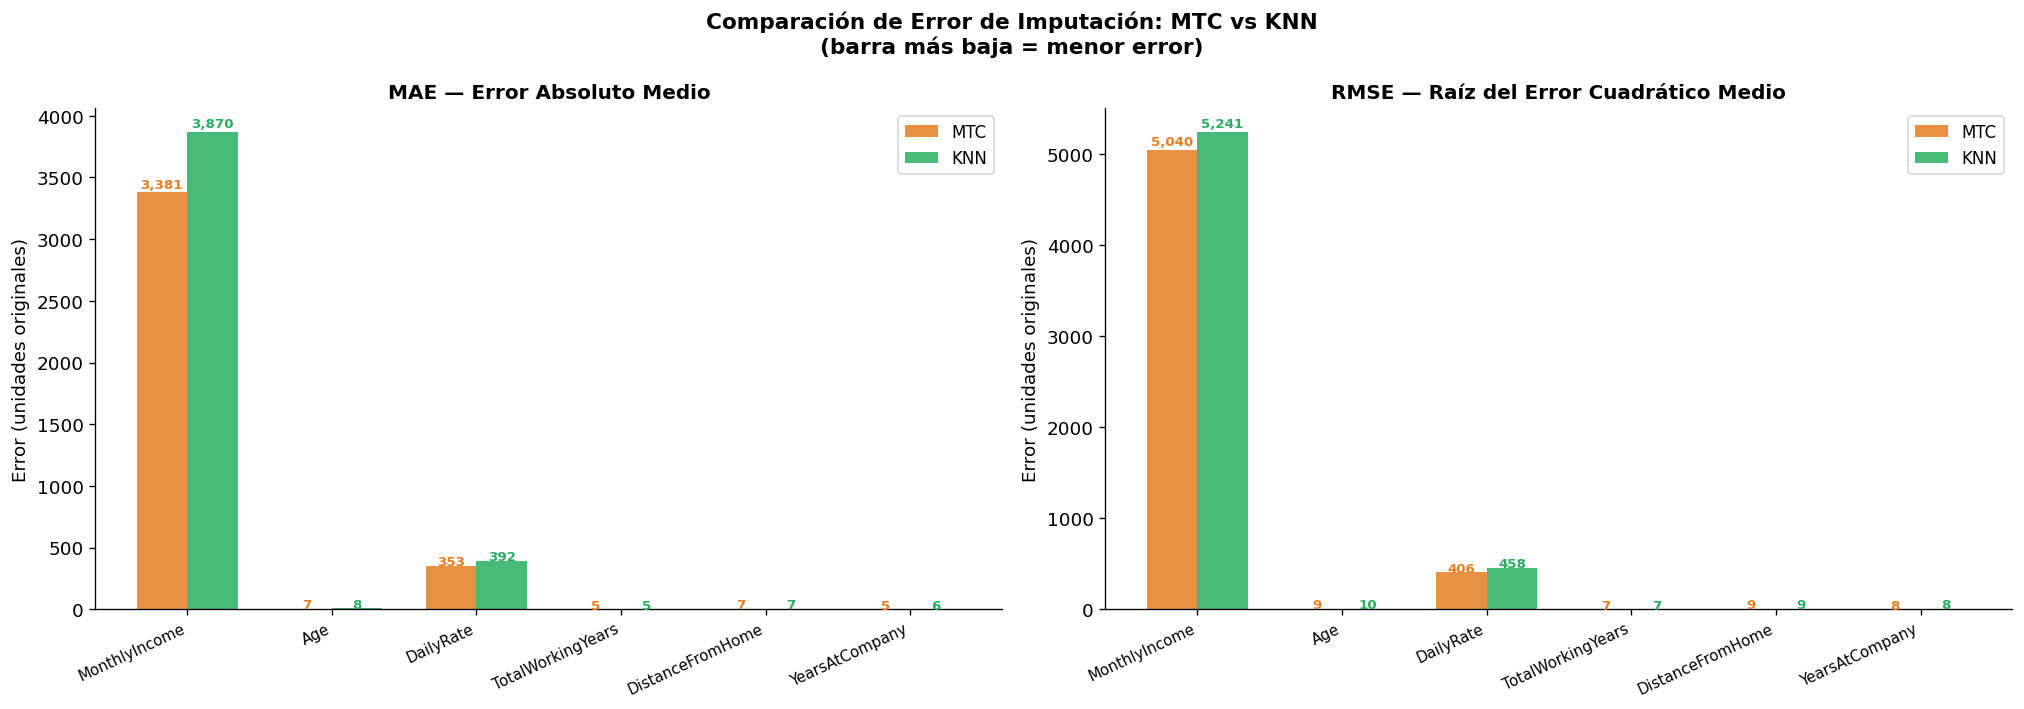

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
x = np.arange(len(err_df))
w = 0.35

for ax, metric, title in [
    (axes[0], ('MAE MTC','MAE KNN'),   'MAE — Error Absoluto Medio'),
    (axes[1], ('RMSE MTC','RMSE KNN'), 'RMSE — Raíz del Error Cuadrático Medio'),
]:
    v_mtc = err_df[metric[0]].values
    v_knn = err_df[metric[1]].values
    b1 = ax.bar(x - w/2, v_mtc, w, label='MTC', color='#e67e22', alpha=0.85)
    b2 = ax.bar(x + w/2, v_knn, w, label='KNN', color='#27ae60', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(err_df.index, rotation=25, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Error (unidades originales)')
    ax.legend(fontsize=10)
    for xi, (vm, vk) in enumerate(zip(v_mtc, v_knn)):
        ax.text(xi-w/2, vm*1.01, f'{vm:,.0f}', ha='center', fontsize=8,
                color='#e67e22', fontweight='bold')
        ax.text(xi+w/2, vk*1.01, f'{vk:,.0f}', ha='center', fontsize=8,
                color='#27ae60', fontweight='bold')

fig.suptitle('Comparación de Error de Imputación: MTC vs KNN\n'
             '(barra más baja = menor error)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_errores_mae_rmse.png', bbox_inches='tight')
plt.show()